# Red Neuronal Convolucional

En este laboratorio vamos a comparar dos tipos de  CNN con una red neuronal clásica en el dataset MNIST 

### SETUP

In [1]:
!pip install -q numpy==2.0.2
!pip install -q pandas==2.2.2
!pip install -q tensorflow_cpu==2.18.0
!pip install -q matplotlib==3.9.2

In [14]:
#Supress warnings
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

#Keras utils
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical
from keras.layers import Conv2D # convolutional layers
from keras.layers import MaxPooling2D # pooling layers
from keras.layers import Flatten # flatten data for fully connected layers

## Dataset
Descarguemos el dataset, hagamos el split de entrenamiento/validación, normalicemos las features, codifiquemos a binario las categorías del target y cambiemos las dimensiones del dataset

In [3]:
#Download dataset
from keras.datasets import mnist

#Load dataset (already splitted)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

#Feature normalization
X_train = X_train / 255 
X_test = X_test / 255 

#Binary encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

#Dataset reshape for cnn
X_train_cnn = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

#Dataset reshape for simple nn
num_pixels = 28*28

X_train_nn = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') 
X_test_nn = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') 

# Modelos

## Creación

Vamos a crear 3 modelos
-   CNN simple, con un set de capa convolucional y agrupamiento


In [4]:
#Output layer must have same number of nodes as classes
num_classes = y_test.shape[1]

simple_cnn_model = Sequential()
simple_cnn_model.add(Input(shape=(28, 28, 1)))

simple_cnn_model.add(Conv2D(16, (5, 5), strides=(1, 1), activation='relu'))
simple_cnn_model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

simple_cnn_model.add(Flatten())
simple_cnn_model.add(Dense(100, activation='relu'))
simple_cnn_model.add(Dense(num_classes, activation='softmax'))

# compile cnn_simple_model
simple_cnn_model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])

-   CNN compleja, con dos sets de capas convolucionales y agrupamiento

In [5]:
complex_cnn_model = Sequential()
complex_cnn_model.add(Input(shape=(28, 28, 1)))

complex_cnn_model.add(Conv2D(16, (5, 5), strides=(1, 1), activation='relu'))
complex_cnn_model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
complex_cnn_model.add(Conv2D(16, (5, 5), strides=(1, 1), activation='relu'))
complex_cnn_model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

complex_cnn_model.add(Flatten())
complex_cnn_model.add(Dense(100, activation='relu'))
complex_cnn_model.add(Dense(num_classes, activation='softmax'))

# compile cnn_simple_model
complex_cnn_model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])

-   Red neuronal clásica <br>
    Recordemos que en este caso tomamos un vector de longitud igual a $N \times M$ donde N y M es el largo de fila,columna de pixeles.

In [6]:
classic_nn_model = Sequential()
classic_nn_model.add(Input(shape=(num_pixels,)))
classic_nn_model.add(Dense(num_pixels, activation='relu'))
classic_nn_model.add(Dense(100,activation='relu'))
classic_nn_model.add(Dense(100,activation='relu'))
classic_nn_model.add(Dense(num_classes,activation='softmax'))

classic_nn_model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])

## Entrenamiento y validación

Entrenemos a los 3 modelos y obtengamos su accuracy para compararlos

In [7]:
simple_cnn_history = simple_cnn_model.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=10, batch_size=200, verbose=0)
complex_cnn_history = complex_cnn_model.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=10, batch_size=200, verbose=0)
classic_nn_history = classic_nn_model.fit(X_train_nn, y_train, validation_data=(X_test_nn , y_test), epochs=10, verbose=0)

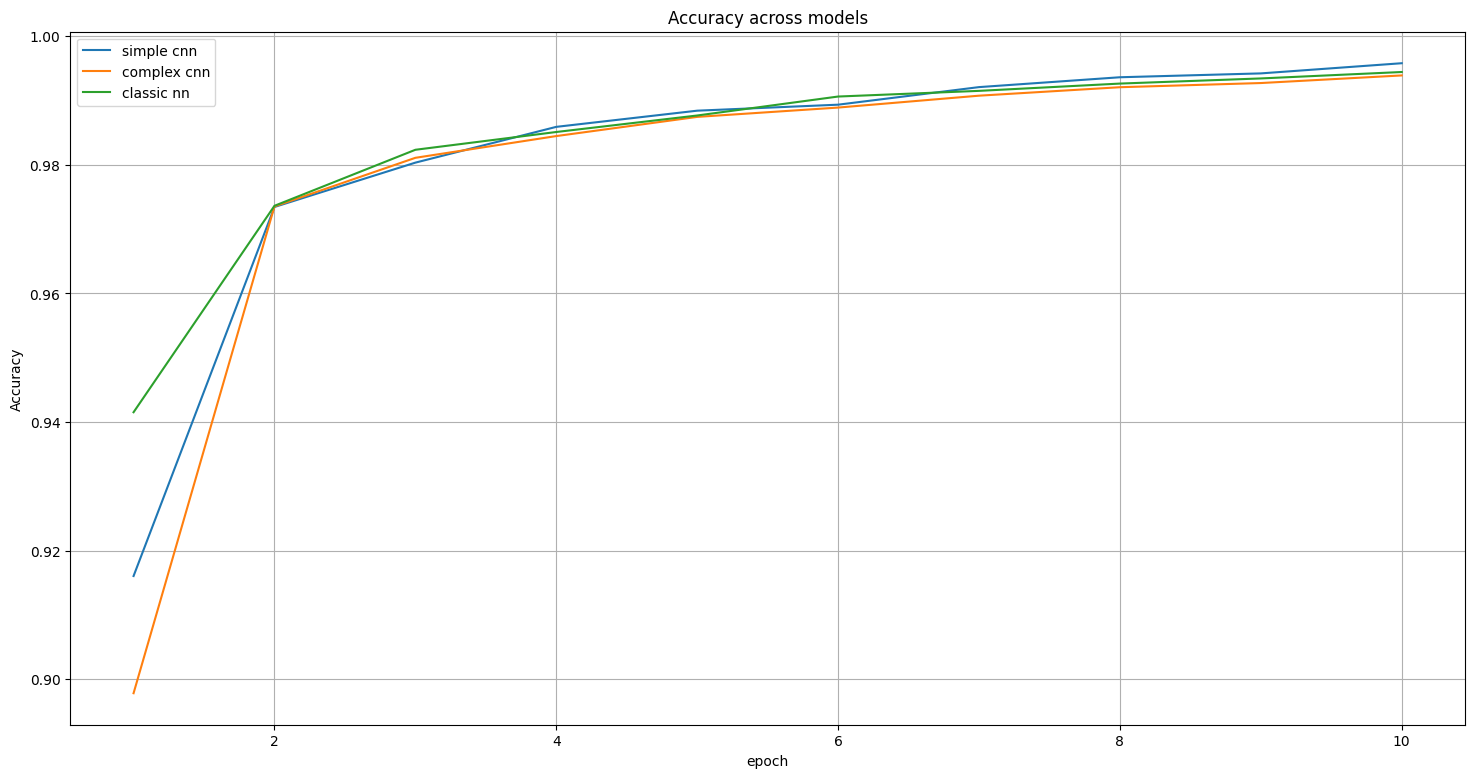

In [18]:
simple_cnn_accuracy = simple_cnn_history.history["accuracy"]
complex_cnn_accuracy = complex_cnn_history.history["accuracy"]
classic_nn_accuracy = classic_nn_history.history["accuracy"]
epochs = np.arange(1,11)

plt.figure(figsize=(18, 9))

# Accuracy
ax = plt.subplot()
ax.plot(epochs,simple_cnn_accuracy, label="simple cnn")
ax.plot(epochs,complex_cnn_accuracy,  label="complex cnn")
ax.plot(epochs,classic_nn_accuracy,  label="classic nn")
ax.set(xlabel="epoch", ylabel="Accuracy", title="Accuracy across models")
ax.legend()
ax.grid()


plt.show()

Podemos ver que los 3 modelos son bastante buenos en sus predicciones, incluso de manera contraintuitiva notamos que la red neuronal clasica empieza con una accuracy mayor a las redes convolucionales. <br> Si bien esto es interesante, habla mas sobre el dataset que los modelos en si, podemos deducir que el problema es relativamente sencillo y nuestras redes lo suficientemente complejas como para encontrar facilmente los patrones necesarios, sin embargo esto no va a ser igual a medida que tomemos datasets con relaciones más complejas y profundas. 